## Visualizing galaxy property maps from GalSyn output
After running the synthesis process, GalSyn produces a comprehensive FITS file containing synthetic imaging, IFU data cubes, and extensive set of physical property maps. This notebook demonstrates how to visualize these spatially resolved phsyical property maps.

/Users/abdurroufabdurrouf/anaconda3/envs/galsynskirt/lib/python3.11/site-packages/astropy/visualization/lupton_rgb.py:645: RuntimeWarning: invalid value encountered in divide
  fInorm = np.where(Int <= 0, 0, np.true_divide(fI, Int))


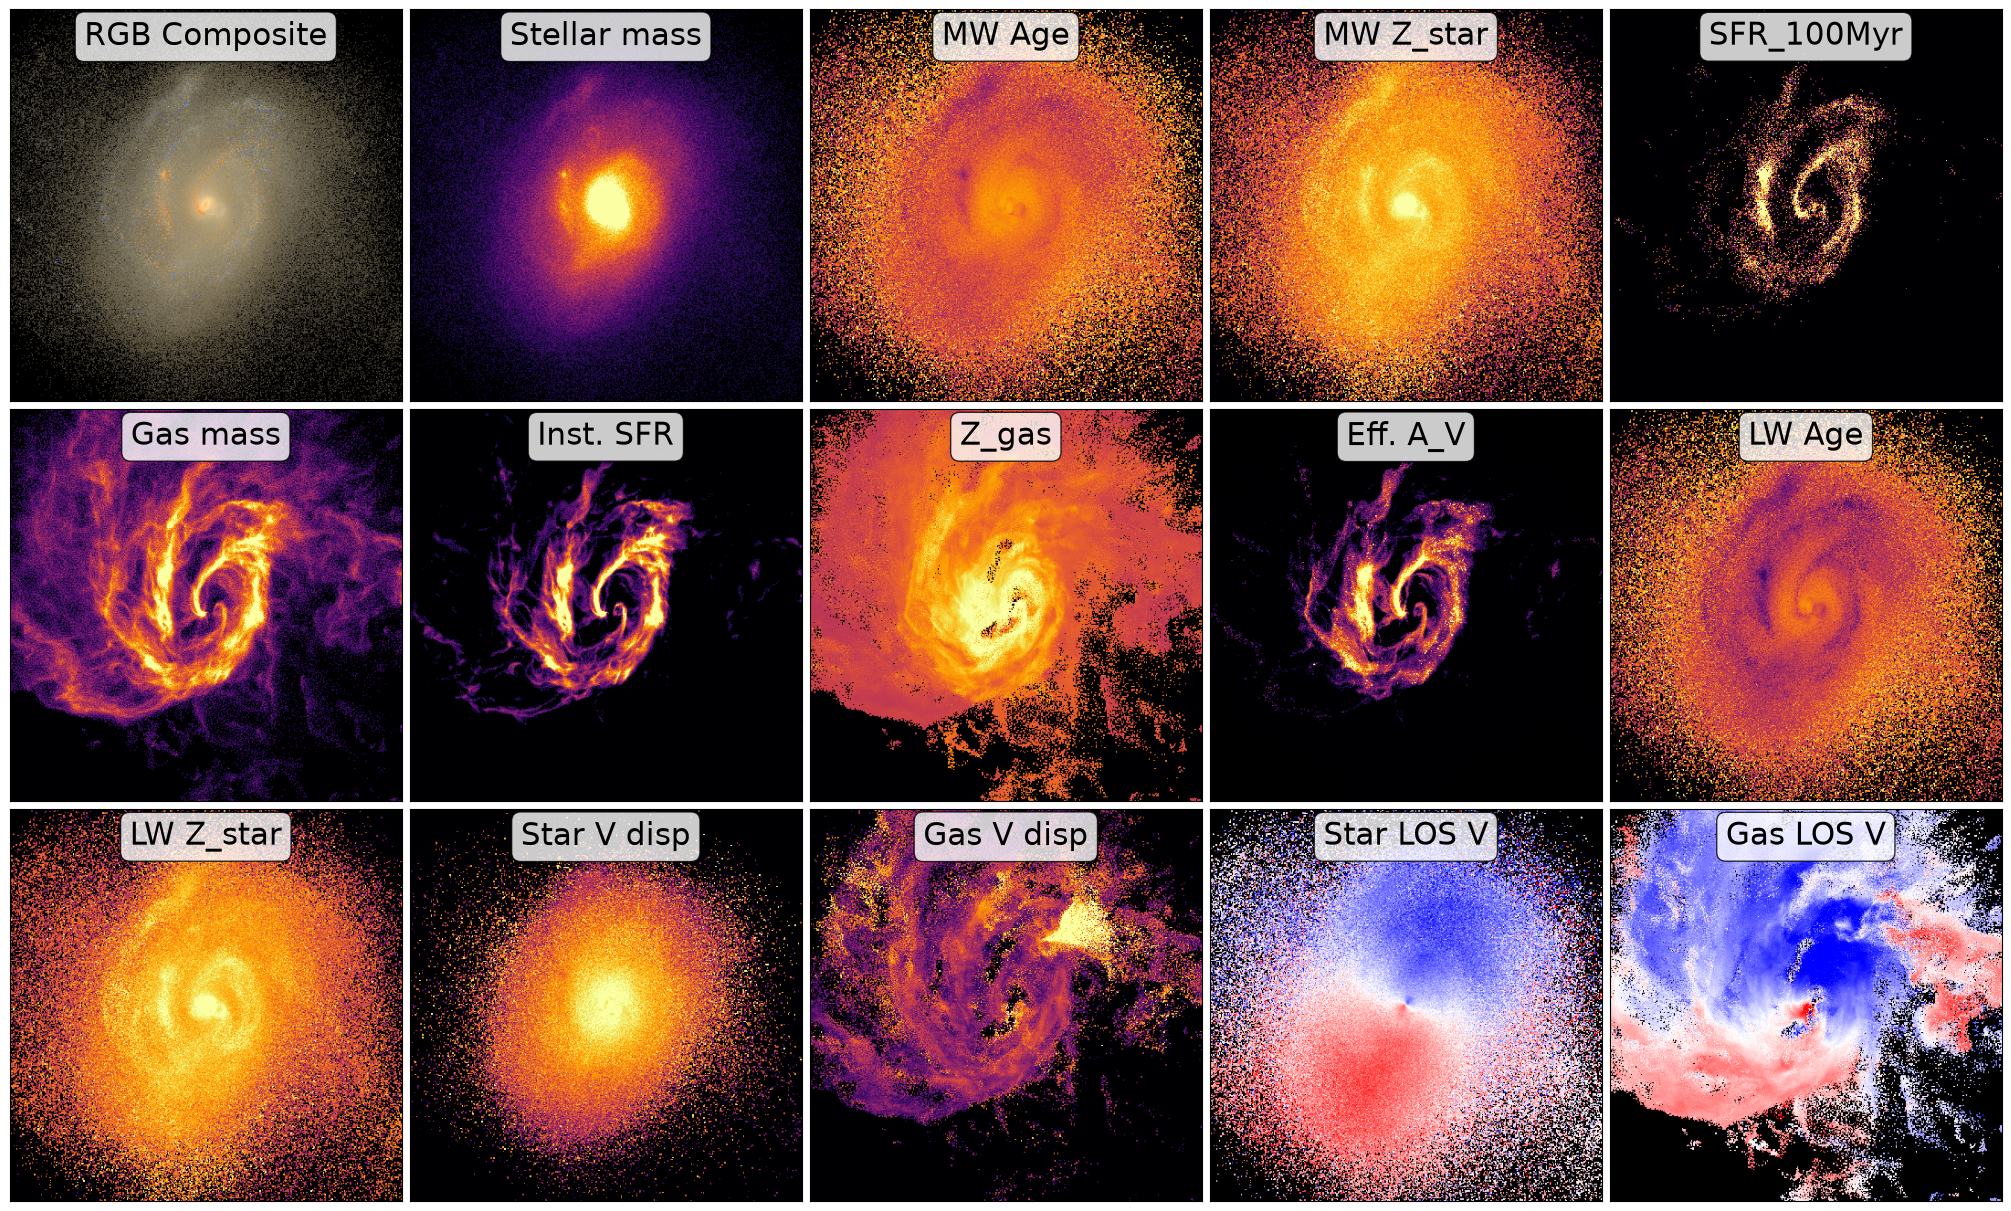

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm 
from astropy.io import fits
from astropy.visualization import simple_norm, make_lupton_rgb

# Input synthetic data cube
fits_filename = 'galsyn_62_132810_specphoto.fits'

# Your specific HDU names and labels
hdu_names = [
    'STARS_MASS', 'MW_AGE', 'STARS_MW_ZSOL', 'SFR_100MYR', 'GAS_MASS', 'SFR_INST', 
    'GAS_MW_ZSOL', 'EFF_A_REST_V', 'LW_AGE_DUST', 'LW_ZSOL_DUST', 
    'STARS_VEL_DISP_LOS', 'GAS_VEL_DISP_LOS', 'STARS_MW_VEL_LOS', 
    'GAS_MW_VEL_LOS'
]

prop_labels = {
    'STARS_MASS':'Stellar mass', 'MW_AGE': 'MW Age', 'STARS_MW_ZSOL': 'MW Z_star', 
    'SFR_100MYR': 'SFR_100Myr', 'GAS_MASS': 'Gas mass', 'SFR_INST': 'Inst. SFR', 
    'GAS_MW_ZSOL': 'Z_gas', 'EFF_A_REST_V': 'Eff. A_V', 'LW_AGE_DUST': 'LW Age', 
    'LW_ZSOL_DUST': 'LW Z_star', 'STARS_VEL_DISP_LOS': 'Star V disp', 
    'GAS_VEL_DISP_LOS': 'Gas V disp', 'STARS_MW_VEL_LOS': 'Star LOS V', 
    'GAS_MW_VEL_LOS': 'Gas LOS V'
}

# RGB Filters from your example
rgb_fils = ['jwst_nircam_f115w', 'jwst_nircam_f150w', 'jwst_nircam_f200w']
rgb_factor = 3e+3

# Open the data cube
hdulist = fits.open(fits_filename)

# Calculate grid (Total = 1 RGB + all hdu_names)
num_plots = len(hdu_names) + 1
ncols = 5
nrows = (num_plots + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), constrained_layout=True)
axes = axes.flatten()

# Panel 1: RGB image
ax_rgb = axes[0]
# Use the DUST_[FILTER] naming convention from your RGB example
r = hdulist[f'DUST_{rgb_fils[2].upper()}'].data * rgb_factor
g = hdulist[f'DUST_{rgb_fils[1].upper()}'].data * rgb_factor
b = hdulist[f'DUST_{rgb_fils[0].upper()}'].data * rgb_factor

rgb_image = make_lupton_rgb(r, g, b, stretch=20, Q=15)
ax_rgb.imshow(rgb_image, origin='lower')
ax_rgb.text(0.5, 0.93, "RGB Composite", transform=ax_rgb.transAxes, 
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8), 
            verticalalignment='center', horizontalalignment='center', fontsize=22)
ax_rgb.set_xticks([])
ax_rgb.set_yticks([])

# Subsequent panels: physical property maps
for i, ext_name in enumerate(hdu_names):
    ax = axes[i + 1] # Offset by 1 to skip the RGB panel
    
    data = hdulist[ext_name].data

    # Inside your loop, before calling ax.imshow:
    if 'VEL_LOS' in ext_name:
        # To see the rotation pattern, we subtract the systemic velocity here, estimated as the
        # mass-weighted mean LOS velocity over all valid pixels. Empty pixels (value = 0) are
        # excluded from this estimate and shown in black.

        mass = hdulist['STARS_MASS'].data
        valid = (data != 0) & np.isfinite(data)
 
        # systemic LOS velocity = mass-weighted mean over the galaxy
        v_sys = np.nansum(mass[valid] * data[valid]) / np.nansum(mass[valid])
        vmap = np.ma.masked_where(~valid, data - v_sys)
        vmap = np.ma.masked_where(vmap == 0.0, vmap)   # also mask pixels whose final velocity is exactly zero

        vmax = np.nanpercentile(np.abs(vmap.compressed()), 98)
        cmap = plt.get_cmap('bwr').copy()
        cmap.set_bad(color='black')   # masked pixels shown in black

        im = ax.imshow(vmap, origin='lower', cmap=cmap, vmin=-vmax, vmax=vmax)

    else:
        cmap = plt.get_cmap('inferno').copy()
        cmap.set_bad(color='black')
        norm = simple_norm(data, 'sqrt', percent=98.0)
        im = ax.imshow(data, norm=norm, origin='lower', cmap=cmap)

    # Labels
    title_label = prop_labels.get(ext_name, ext_name)
    ax.text(0.5, 0.93, title_label, transform=ax.transAxes, 
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8), 
            verticalalignment='center', horizontalalignment='center', fontsize=22)
    
    ax.set_xticks([])
    ax.set_yticks([])

hdulist.close()

plt.show()